In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filename = 'data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits'

with fits.open(filename) as hdul:
    hdul.info()
    print(hdul[1].columns)

Filename: data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (678,)   uint8   
  1  /Users/buder/Simulations/preparing_NIHAO/NIHAO_prepared/NIHAO_g8.26e    1 BinTableHDU     21   511520R x 4C   [E, E, E, D]   
ColDefs(
    name = 'x'; format = 'E'
    name = 'y'; format = 'E'
    name = 'z'; format = 'E'
    name = 'A_O'; format = 'D'
)


In [3]:
with fits.open(filename) as hdul:
    data = hdul[1].data

x = data['x']
y = data['y']
z = data['z']
A_O = data['A_O']

R_gal = np.sqrt(x**2 + y**2)

print(f"Number of gas particles: {len(A_O)}")
print(f"R_gal range: {R_gal.min():.2f} to {R_gal.max():.2f} kpc")
print(f"A(O) range: {A_O.min():.2f} to {A_O.max():.2f}")

Number of gas particles: 511520
R_gal range: 0.03 to 25.00 kpc
A(O) range: 7.68 to 9.25


In [4]:
from scipy import optimize

def linear_func(R, slope, intercept):
    return slope * R + intercept

popt, pcov = optimize.curve_fit(linear_func, R_gal, A_O)
slope, intercept = popt
slope_err, intercept_err = np.sqrt(np.diag(pcov))

print(f"Slope: {slope:.4f} +/- {slope_err:.4f}")
print(f"Intercept: {intercept:.4f} +/- {intercept_err:.4f}")

Slope: -0.0342 +/- 0.0000
Intercept: 9.1278 +/- 0.0002


## Point 1: 2 Figure Panel

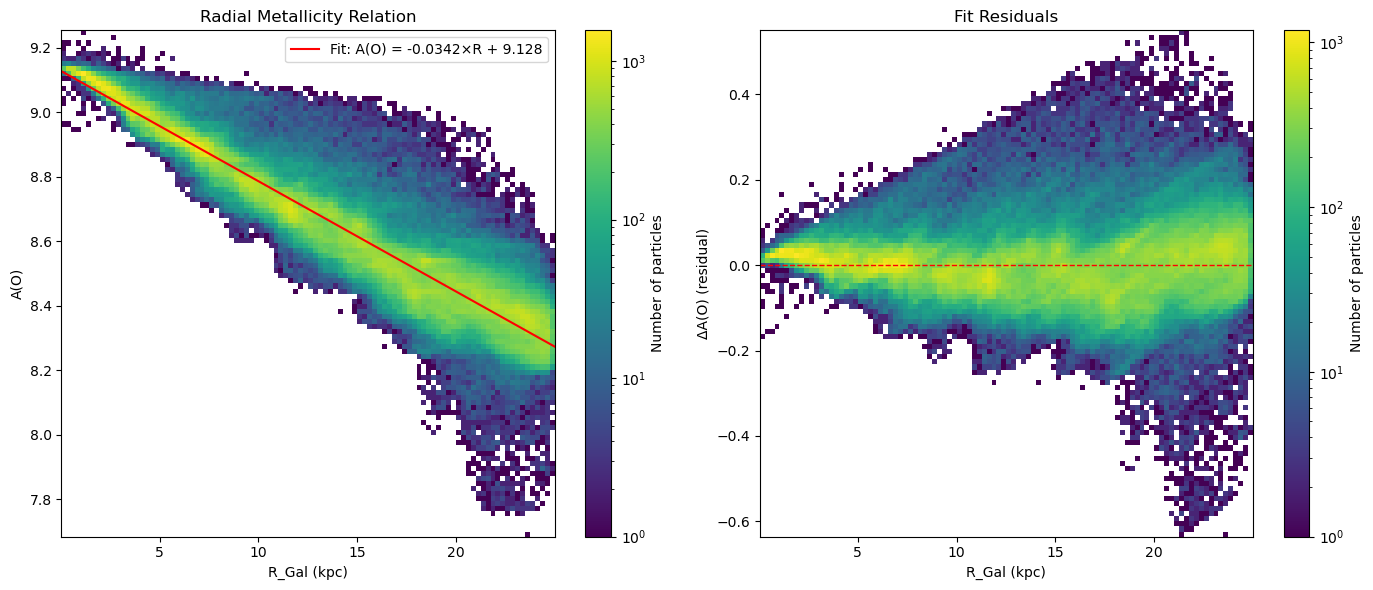

In [5]:
residuals = A_O - linear_func(R_gal, slope, intercept)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel (a): logarithmic density plot with fit
h1 = axes[0].hist2d(R_gal, A_O, bins=100, cmap='viridis', norm='log')
plt.colorbar(h1[3], ax=axes[0], label='Number of particles')
r_line = np.linspace(R_gal.min(), R_gal.max(), 100)
axes[0].plot(r_line, linear_func(r_line, slope, intercept), 'r-',
             label=f'Fit: A(O) = {slope:.4f}×R + {intercept:.3f}')
axes[0].set_xlabel('R_Gal (kpc)')
axes[0].set_ylabel('A(O)')
axes[0].set_title('Radial Metallicity Relation')
axes[0].legend()

# Panel (b): residuals
h2 = axes[1].hist2d(R_gal, residuals, bins=100, cmap='viridis', norm='log')
plt.colorbar(h2[3], ax=axes[1], label='Number of particles')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('R_Gal (kpc)')
axes[1].set_ylabel('ΔA(O) (residual)')
axes[1].set_title('Fit Residuals')

plt.tight_layout()
plt.savefig('figures/radial_metallicity_fit.png', dpi=150)
plt.show()

## Point 2: Linear Fit Results

Using scipy.optimize.curve_fit (least-squares; no hyperparameters other than default Levenberg-Marquardt method): 

- Slope: -0.0342 ± 0.0000 dex/kpc
- Intercept: 9.1278 ± 0.0002 dex

The fact that the slope is negative suggests that there is a metallicity gradient which decreases with galactocentric radius, which is consistent with inside-out disc formation.

In [6]:
rms_overall = np.sqrt(np.mean(residuals**2))
print(f"Overall RMS: {rms_overall:.4f} dex")

# Check RMS in radial bins to see where the fit does worse
bin_edges = np.array([0, 5, 10, 15, 20, 25])
for i in range(len(bin_edges) - 1):
    mask = (R_gal >= bin_edges[i]) & (R_gal < bin_edges[i+1])
    rms_bin = np.sqrt(np.mean(residuals[mask]**2))
    print(f"R = {bin_edges[i]}-{bin_edges[i+1]} kpc: RMS = {rms_bin:.4f} dex, N = {mask.sum()}")

Overall RMS: 0.0726 dex
R = 0-5 kpc: RMS = 0.0323 dex, N = 65587
R = 5-10 kpc: RMS = 0.0483 dex, N = 94246
R = 10-15 kpc: RMS = 0.0704 dex, N = 100223
R = 15-20 kpc: RMS = 0.0879 dex, N = 122081
R = 20-25 kpc: RMS = 0.0866 dex, N = 129383


## Point 3: Where the linear model fits well discussion

**Overall RMS: 0.0726 dex**

The following trend was revealed once the RMS was broken into radial bins:
R = 0-5 kpc: RMS = 0.0323 dex, N = 65587
R = 5-10 kpc: RMS = 0.0483 dex, N = 94246
R = 10-15 kpc: RMS = 0.0704 dex, N = 100223
R = 15-20 kpc: RMS = 0.0879 dex, N = 122081
R = 20-25 kpc: RMS = 0.0866 dex, N = 129383

The linear model works well in the innermost bin (R = 0-5 kpc, RMS = 0.0323 dex), and gets increasingly worse in each subsequent bin, acheiving ∼2.7 times the innermost RMS in the bin at R = 15-20 kpc (0.0879 dex). This corresponds to the earlier residual plot, which shows that the spread around zero decreases toward the center and increases with radius.

The poor fit occurs in the outer disc region (R > 15 kpc), where RMS levels out at 0.087 to 0.088 dex. This can be seen from the residual diagram showing a second population of particles in the lower branch, far away from the main trend line, which raises the local RMS significantly due to the inability to fit two populations with one global linear regression.

## Point 4: 3 Panel xy Plane maps

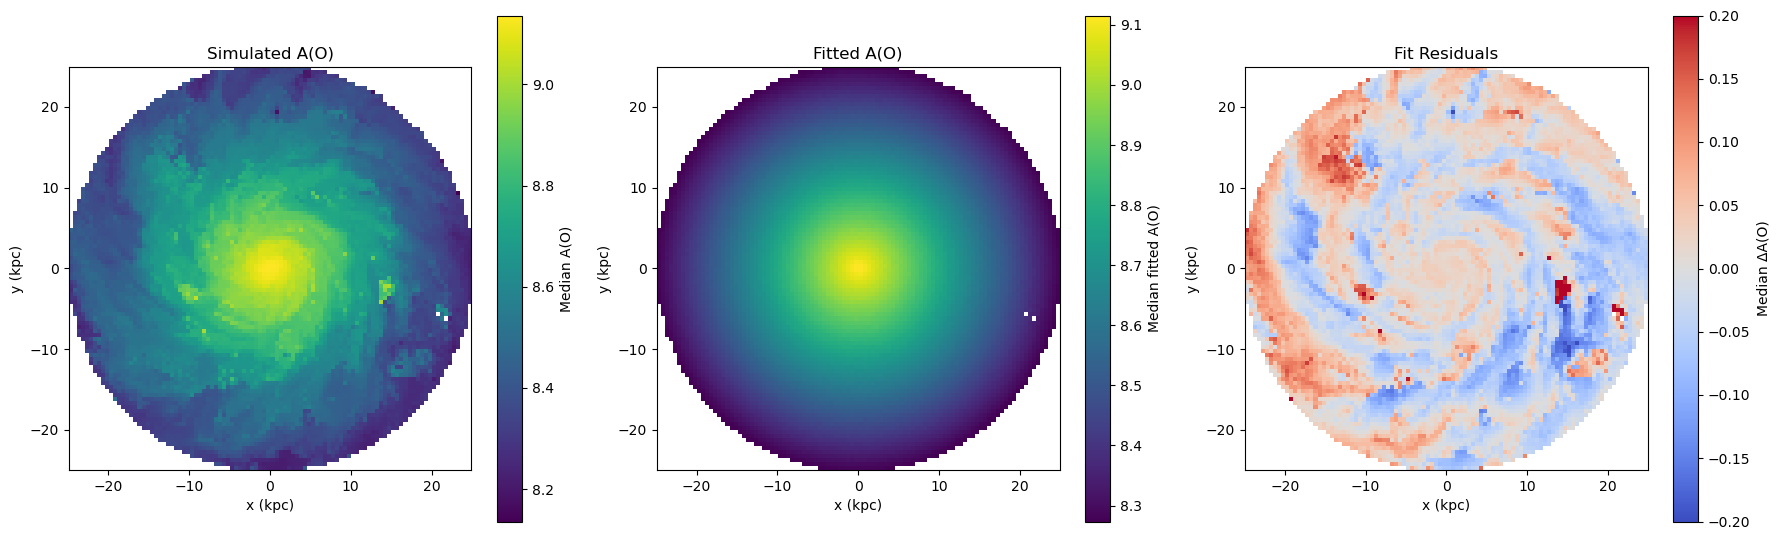

In [14]:
from scipy.stats import binned_statistic_2d

nbins = 100
fitted_A_O = linear_func(R_gal, slope, intercept)

stat_actual, xedges, yedges, _ = binned_statistic_2d(
    x, y, A_O, statistic='median', bins=nbins)
stat_fitted, _, _, _ = binned_statistic_2d(
    x, y, fitted_A_O, statistic='median', bins=[xedges, yedges])
stat_resid, _, _, _ = binned_statistic_2d(
    x, y, residuals, statistic='median', bins=[xedges, yedges])

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

im0 = axes[0].imshow(stat_actual.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap='viridis', aspect='equal')
plt.colorbar(im0, ax=axes[0], label='Median A(O)')
axes[0].set_title('Simulated A(O)')
axes[0].set_xlabel('x (kpc)')
axes[0].set_ylabel('y (kpc)')

im1 = axes[1].imshow(stat_fitted.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap='viridis', aspect='equal')
plt.colorbar(im1, ax=axes[1], label='Median fitted A(O)')
axes[1].set_title('Fitted A(O)')
axes[1].set_xlabel('x (kpc)')
axes[1].set_ylabel('y (kpc)')

im2 = axes[2].imshow(stat_resid.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap='coolwarm', aspect='equal', vmin=-0.2, vmax=0.2)
plt.colorbar(im2, ax=axes[2], label='Median ΔA(O)')
axes[2].set_title('Fit Residuals')
axes[2].set_xlabel('x (kpc)')
axes[2].set_ylabel('y (kpc)')

plt.tight_layout()
plt.savefig('figures/radial_metallicity_xy_panels.png', dpi=150)
plt.show()

In [16]:
counts, _, _, _ = binned_statistic_2d(x, y, A_O, statistic='count', bins=[xedges, yedges])
nonzero_counts = counts[counts > 0]

print(f"Median particles per non-empty bin: {np.median(nonzero_counts):.0f}")
print(f"Minimum particles per non-empty bin: {nonzero_counts.min():.0f}")
print(f"Fraction of bins with <5 particles: {(nonzero_counts < 5).mean():.2%}")

Median particles per non-empty bin: 40
Minimum particles per non-empty bin: 1
Fraction of bins with <5 particles: 2.16%


## Point 5: Choice of 2D bins

The choice of 2D bins here was 100 x 100 bins on the xy plane (this is about ±25 kpc in both directions), so the bins here were about 0.5 kpc in size.

With 511,520 total counts, the median non-empty bin has 40 counts, and just 2.16% of bins have less than 5 counts, so the median A(O)/residual value for each bin should usually be well-determined, though there may be some less reliable values from sparse outer bins with the minimum possible 1 count.

Smaller number of bins (20-30 bins per axis, bins sizes 1.5-2 kpc) would smooth the spiral pattern seen on the residual map and turn it into a less informative diffuse pattern where we wouldn't see the narrow overdensities corresponding to spiral arms clearly.

Using more bins (300 or more per axis, bins of <0.2 kpc) would mean the possibility of very sparsely populated bins, thereby leading to noise in the calculation of the median and ultimately leading to a noisy map where the structure is not visible.

The choice of 100 bins was selected to strike a good balance: fine enough to reveal the spiral pattern clearly (based on the residuals plot), but with most of the bins having enough data for a reliable median calculation. 

In [17]:
theta = np.arctan2(y, x)  # azimuthal angle in radians

annulus_mask = (R_gal > 10) & (R_gal < 15)
theta_bins = np.linspace(-np.pi, np.pi, 13)  
bin_indices = np.digitize(theta[annulus_mask], theta_bins)

annulus_residuals = residuals[annulus_mask]
bin_medians = [np.median(annulus_residuals[bin_indices == i]) for i in range(1, len(theta_bins))]

print("Median residual by azimuthal bin (R = 10-15 kpc):")
for i, med in enumerate(bin_medians):
    angle_deg = np.degrees((theta_bins[i] + theta_bins[i+1]) / 2)
    print(f"  θ ≈ {angle_deg:6.1f}°: ΔA(O) = {med:+.4f} dex")

print(f"\nRange of azimuthal medians: {max(bin_medians) - min(bin_medians):.4f} dex")

Median residual by azimuthal bin (R = 10-15 kpc):
  θ ≈ -165.0°: ΔA(O) = -0.0176 dex
  θ ≈ -135.0°: ΔA(O) = -0.0232 dex
  θ ≈ -105.0°: ΔA(O) = -0.0192 dex
  θ ≈  -75.0°: ΔA(O) = -0.0370 dex
  θ ≈  -45.0°: ΔA(O) = -0.0648 dex
  θ ≈  -15.0°: ΔA(O) = -0.0336 dex
  θ ≈   15.0°: ΔA(O) = -0.0133 dex
  θ ≈   45.0°: ΔA(O) = +0.0001 dex
  θ ≈   75.0°: ΔA(O) = +0.0039 dex
  θ ≈  105.0°: ΔA(O) = -0.0267 dex
  θ ≈  135.0°: ΔA(O) = -0.0333 dex
  θ ≈  165.0°: ΔA(O) = +0.0140 dex

Range of azimuthal medians: 0.0788 dex


## Point 6: Physical explanation of patterns observed.

From the graph of the residuals (Point 4c), it is evident that a spiral pattern exists and not just noise, as can be seen in the form of a coherent red/blue swirl pattern that seems to trace the spiral structure of the galaxy.

To ensure that this is truly a systematic effect and not an illusion, the median residual value at constant radius (R = 10-15 kpc) was examined throught 12 azimuthal bins. The median residuals fall between -0.065 and +0.014 dex, a difference of 0.079 dex, which is about the same magnitude as the fit RMS in total.

**Physical Explanation:** Spiral arms represent gas-rich environments where star formation is ongoing or has recently taken place. Given that A(O) represents gas oxygen abundance, the following may have physical effects:

- Enrichment recently acquired: spiral arms promote active star formation, which leads to an enrishment of oxygen in arm gar (due to core-collapse supernovae) faster than interarm gas at the same radius.
- Radial migration and streaming: spiral arms influence the orbits of stars and gas, leading to radial mixing and transport of gas of high or low metallicity compared to the axissymmetric assumption.
- Streaming flows in the gaseous component: in the spiral arms mean gas at a certain (x,y) position did not necessarily originate there, further violating the assumption of a radial metallicity dependency.

For the global linear fit, which is just based on R_Gal and not angle, it is fundamentally incapable of reproducing the contrast between the arms and interarms; this is why we see this particular structure show up in the residual, rather than being incorporated in the fit.